In [2]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fft as fft
import seaborn as sns
import torch
from scipy.stats import genextreme, genpareto, pareto
import importlib
import wxderivs
importlib.reload(wxderivs)

from wxderivs import (
    DIR_WORK,
    MONTH_CDD,
    MONTH_HDD,
    SET_TARGET_US_CITIES,
    SET_CDD,
    SET_HDD,
    SET_USA,
    dct_name_file,
    fit_mean_std,
)



sys.path.append(str(DIR_WORK / "unibm"))

import unibm
import unibm.benchmark


0 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Essen.csv
1 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Boston.csv
2 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Philadelphia.csv
3 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/NewYork.csv
4 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Burbank.csv
5 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/London.csv
6 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Dallas.csv
7 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Paris.csv
8 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Portland.csv
9 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/tempe

In [3]:
df_max_all = {}
df_min_all = {}

for name in SET_USA:
    tmp_df = pd.read_csv(dct_name_file[name])
    tmp_df.index = pd.to_datetime(tmp_df["DATE"])
    df_max_all[name] = tmp_df["DAILY_MAX_TEMP"]
    df_min_all[name] = tmp_df["DAILY_MIN_TEMP"]
df_max_all = pd.DataFrame(df_max_all)
df_min_all = pd.DataFrame(df_min_all)
df_avg_all = (df_max_all + df_min_all) / 2
df_y = df_avg_all
df_max_all.head()

,Chicago,Minneapolis,Burbank,Cincinnati,Portland,Atlanta,Houston,LasVegas,Dallas,Philadelphia,Boston,Sacramento,NewYork
DATE,,,,,,,,,,,,,
2005-01-01,41.0,28.0,54.0,54.0,43.0,69.0,75.0,56.0,74.0,64.0,52.0,54.0,58.0
2005-01-02,54.0,28.0,58.0,58.0,45.0,68.0,73.0,52.0,68.0,47.0,40.0,48.0,48.0
2005-01-03,36.0,16.0,53.0,59.0,43.0,68.0,79.0,47.0,76.0,57.0,53.0,49.0,56.0
2005-01-04,35.0,16.0,51.0,58.0,40.0,71.0,73.0,53.0,70.0,55.0,45.0,49.0,49.0
2005-01-05,31.0,9.0,55.0,46.0,41.0,68.0,77.0,50.0,68.0,47.0,40.0,50.0,45.0


In [4]:
def plot_day_of_year(
    srs,
    is_day_of_year_frac=False,
    is_scatter=False,
    alpha=0.7,
    is_label=False,
    xlabel="Day of year",
    ylabel="Temperature",
    title="Temperature vs Day of year",
    axhline=[
        65,
    ],
    axvline_red=pd.DatetimeIndex(["2020-05-01", "2020-09-30"]).day_of_year.to_list(),
    axvline_blue=pd.DatetimeIndex(["2020-11-01", "2020-03-31"]).day_of_year.to_list(),
    ax=None,
):
    if is_day_of_year_frac:
        vec_t = (srs.index.day_of_year / (srs.index.is_leap_year + 365)).to_numpy()
    else:
        vec_t = srs.index.day_of_year.to_numpy()
    vec_y = srs.to_numpy()
    year_unique = srs.index.year.unique()
    cmap = plt.get_cmap("rainbow", len(year_unique))
    color_map = {year: cmap(i) for i, year in enumerate(year_unique)}
    if ax is None:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    for year in year_unique:
        idx = srs.index.year == year
        if is_scatter:
            ax.scatter(
                vec_t[idx],
                vec_y[idx],
                s=1,
                color=color_map[year],
                alpha=alpha,
                label=year if is_label else None,
            )
        else:
            ax.plot(
                vec_t[idx],
                vec_y[idx],
                label=year,
                alpha=alpha,
                lw=1,
                c=color_map[year],
                linestyle="-.",
            )
    if axhline:
        for _ in axhline:
            ax.axhline(_, color="black", linestyle="--", lw=0.9)
    if axvline_red:
        for _ in axvline_red:
            ax.axvline(_, color="red", linestyle="--", lw=0.9)
    if axvline_blue:
        for _ in axvline_blue:
            ax.axvline(_, color="blue", linestyle="--", lw=0.9)
    ax.grid()
    if is_label:
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

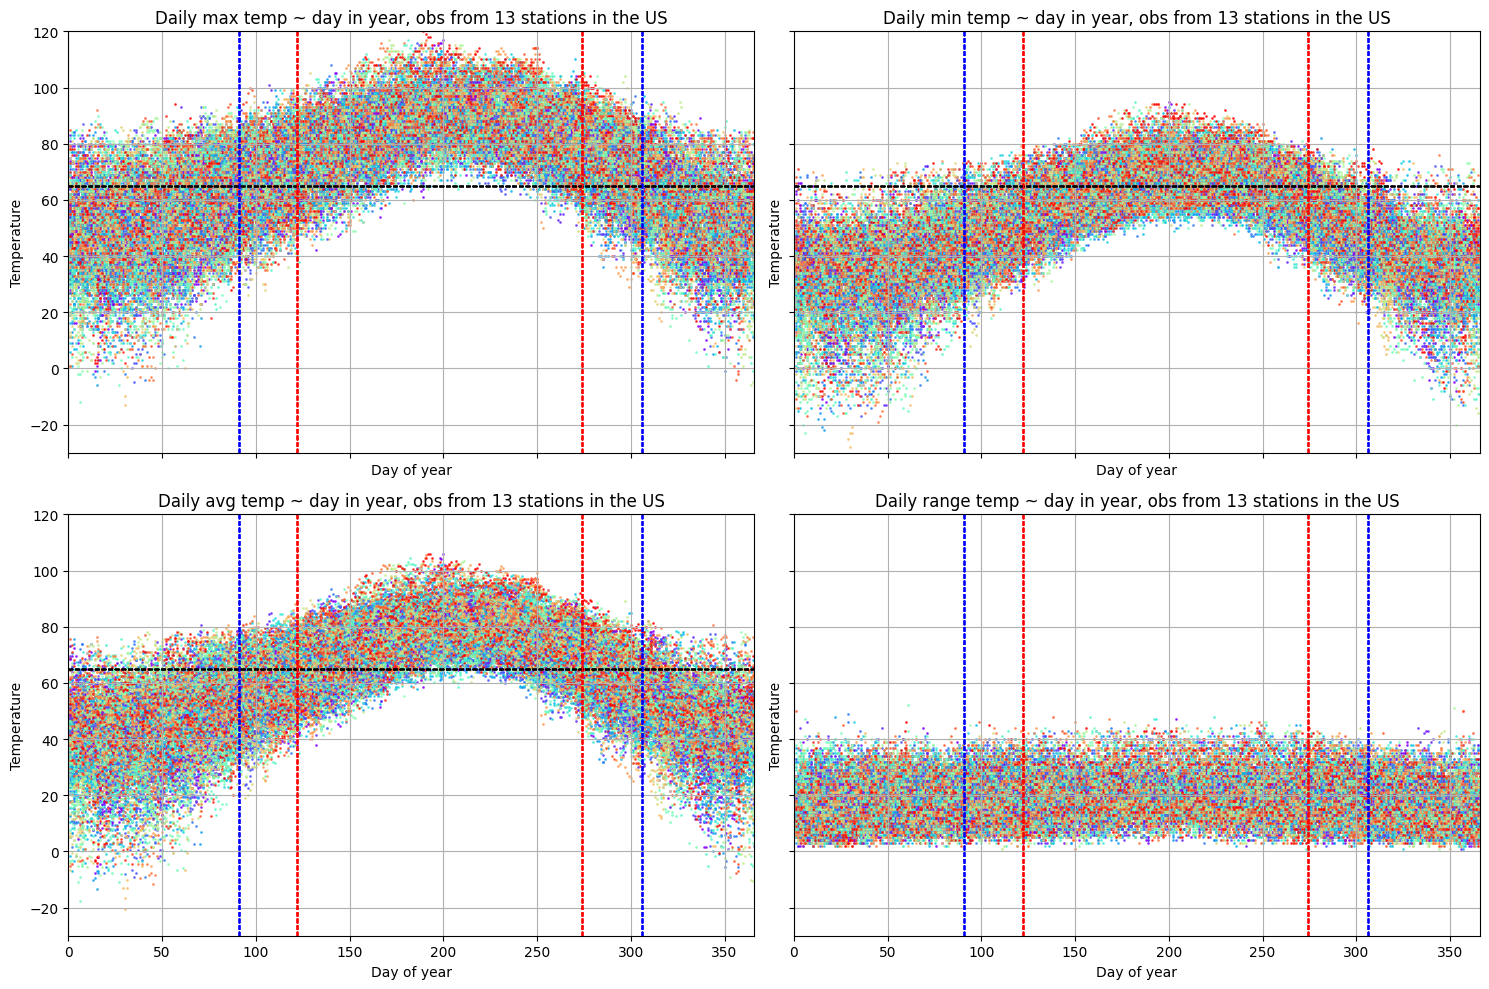

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True)
for station in SET_USA:
    plot_day_of_year(
        df_max_all[station],
        is_scatter=True,
        title="Daily max temp ~ day in year, obs from 13 stations in the US",
        ax=axes[0, 0],
    )
    plot_day_of_year(
        df_min_all[station],
        is_scatter=True,
        title="Daily min temp ~ day in year, obs from 13 stations in the US",
        ax=axes[0, 1],
    )
    plot_day_of_year(
        (df_max_all[station] + df_min_all[station]) / 2,
        is_scatter=True,
        title="Daily avg temp ~ day in year, obs from 13 stations in the US",
        ax=axes[1, 0],
    )
    plot_day_of_year(
        df_max_all[station] - df_min_all[station],
        is_scatter=True,
        title="Daily range temp ~ day in year, obs from 13 stations in the US",
        ax=axes[1, 1],
        axhline=None,
    )
for ax in axes.flatten():
    ax.set_xlim(0, 366)
    ax.set_ylim(-30, 120)
plt.tight_layout()

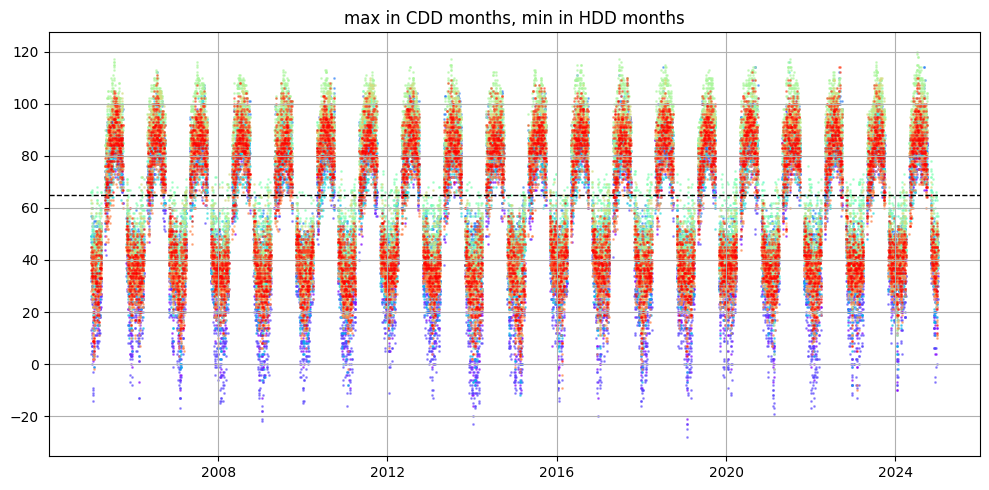

In [6]:
cmap = plt.get_cmap("rainbow", len(SET_USA))
color_map = {year: cmap(i) for i, year in enumerate(SET_USA)}
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
for station in SET_USA:
    idx = df_max_all.index.month.isin(MONTH_CDD)
    ax.scatter(
        df_max_all[idx].index,
        df_max_all[idx][station],
        s=1,
        alpha=0.5,
        color=color_map[station],
        label=f"max, CDD months, {station}",
    )
    idx = df_min_all.index.month.isin(MONTH_HDD)
    ax.scatter(
        df_min_all[idx].index,
        df_min_all[idx][station],
        s=1,
        alpha=0.5,
        color=color_map[station],
        label=f"min, HDD months, {station}",
    )
plt.axhline(65, color="black", linestyle="--", lw=1)
plt.title("max in CDD months, min in HDD months")
# plt.legend()
plt.grid()
plt.tight_layout()

In [7]:
dct_fit_res = {}
for station in SET_TARGET_US_CITIES:
    dct_fit_res[station] = fit_mean_std(
        srs=(df_max_all[station] + df_min_all[station]) / 2
    )

/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:126: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  + alpha * vec_res[i - 1] ** 2
/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:127: RuntimeWarning: overflow encountered in scalar power
  + beta * vec_variance[i - 1] ** 2
/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:126: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  + alpha * vec_res[i - 1] ** 2
/workspaces/Financial-Engineering-Project/notebooks/wxderivs/__init__.py:127: RuntimeWarning: overflow encountered in scalar power
  + beta * vec_var

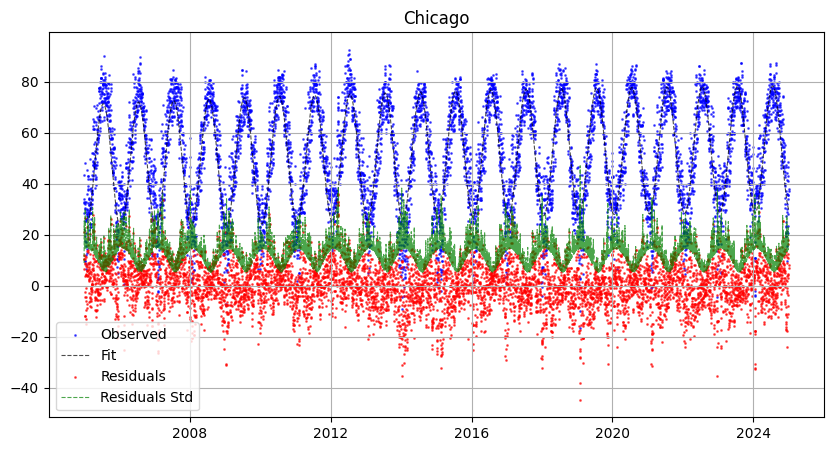

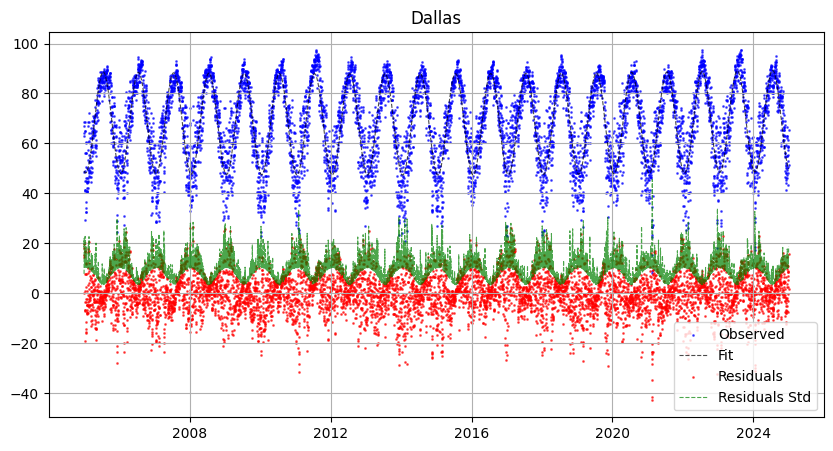

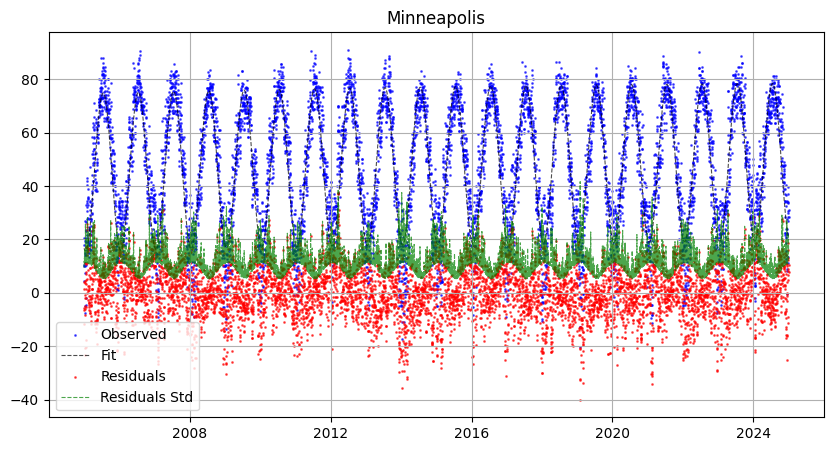

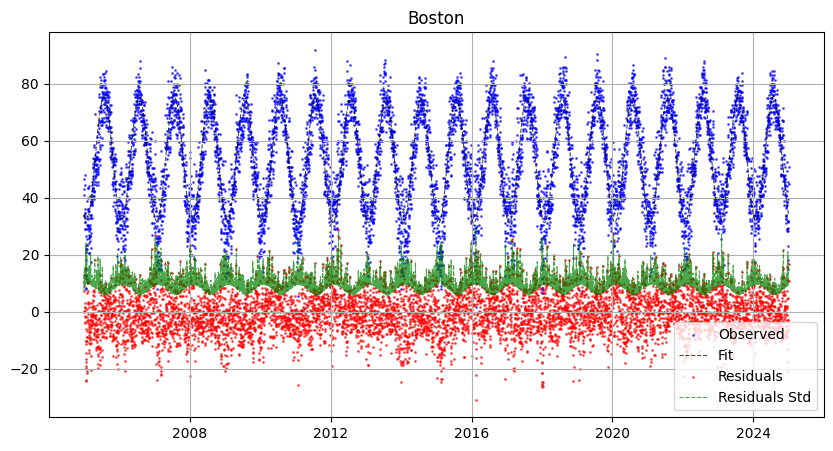

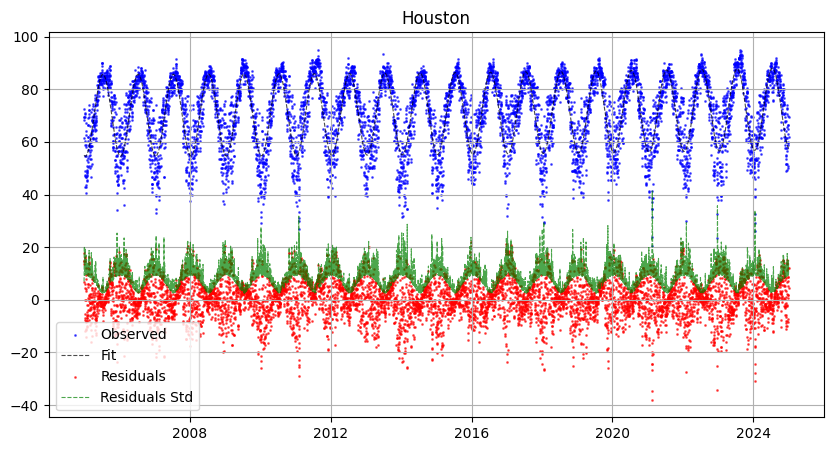

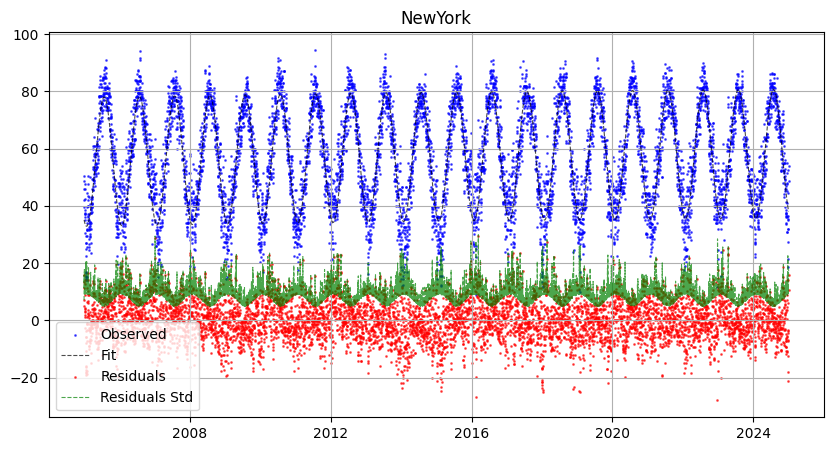

In [8]:
for station in SET_TARGET_US_CITIES:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    ax.set_title(f"{station}")
    ax.scatter(
        x=dct_fit_res[station]["vec_index"],
        y=dct_fit_res[station]["vec_y"],
        s=1,
        color="blue",
        alpha=0.6,
        label="Observed",
    )
    ax.plot(
        dct_fit_res[station]["vec_index"],
        dct_fit_res[station]["vec_y_pred"],
        linewidth=0.8,
        alpha=0.7,
        label="Fit",
        color="black",
        linestyle="--",
    )
    ax.scatter(
        x=dct_fit_res[station]["vec_index"],
        y=dct_fit_res[station]["vec_res"],
        s=1,
        color="red",
        alpha=0.6,
        label="Residuals",
    )
    ax.plot(
        dct_fit_res[station]["vec_index"],
        dct_fit_res[station]["vec_std"],
        linewidth=0.8,
        alpha=0.7,
        label="Residuals Std",
        color="green",
        linestyle="--",
    )
    ax.grid(True)
    ax.legend()
    
    if station == "NewYork":
        plt.savefig("New_York.svg", format='svg')

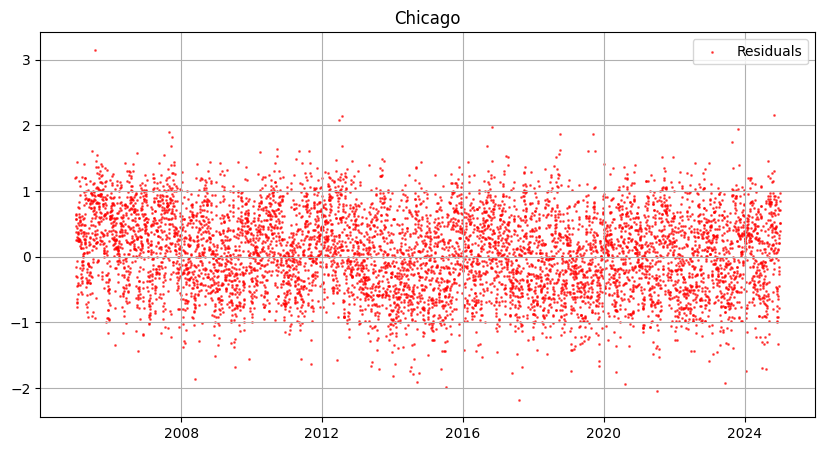

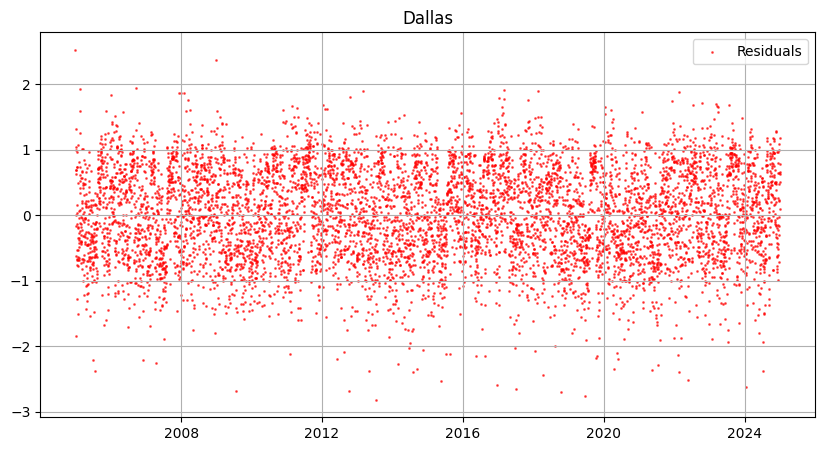

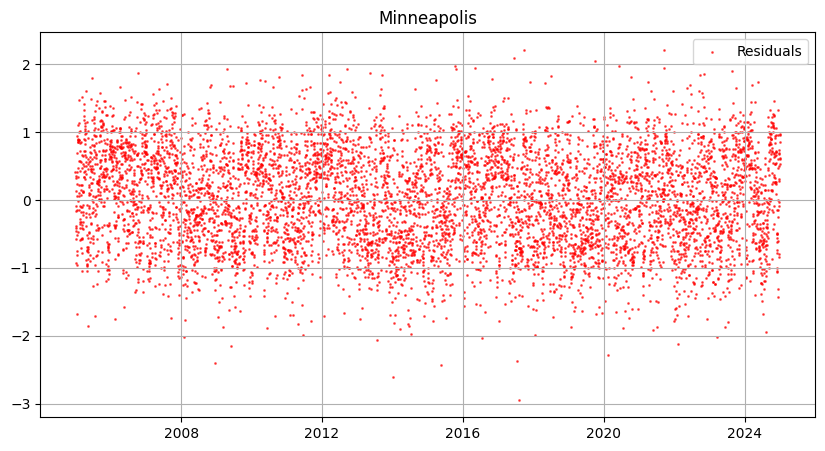

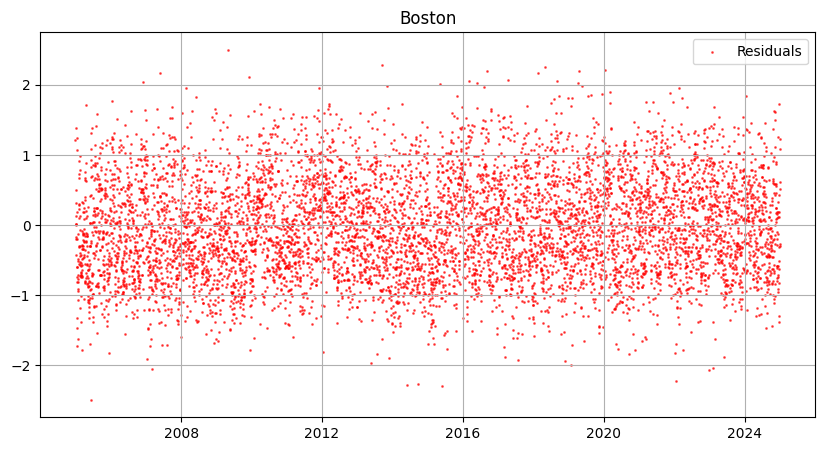

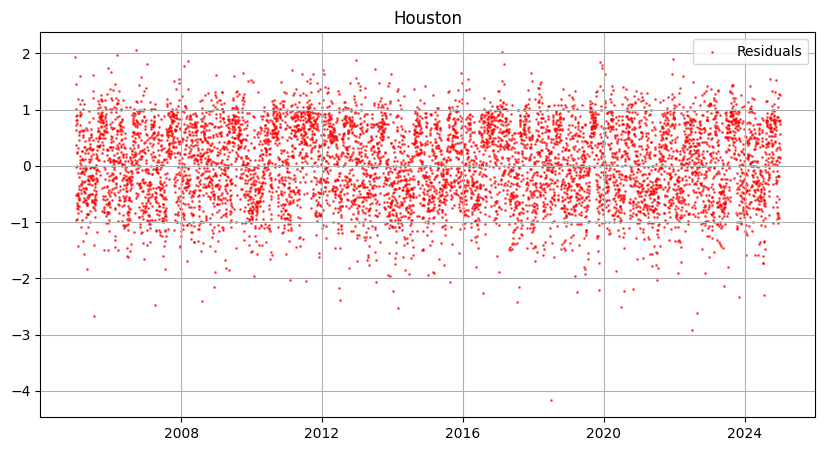

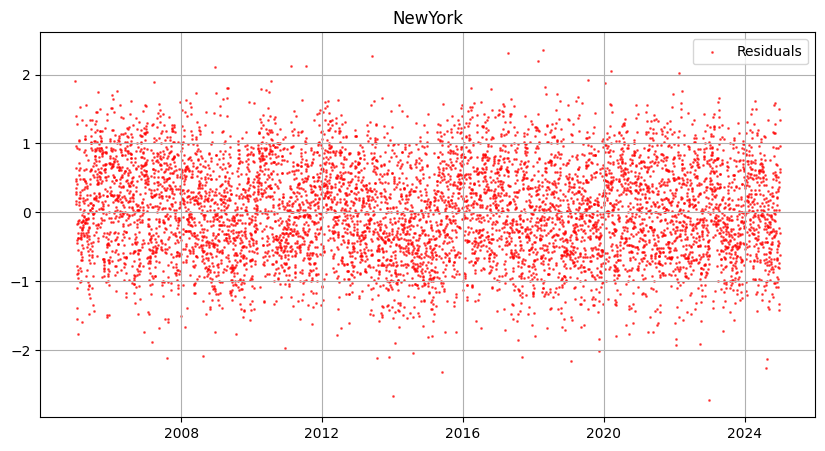

In [9]:
for station in SET_TARGET_US_CITIES:
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    ax.set_title(f"{station}")
    ax.scatter(
        x=dct_fit_res[station]["vec_index"],
        y=dct_fit_res[station]["vec_res_scaled"],
        s=1,
        color="red",
        alpha=0.6,
        label="Residuals",
    )
    ax.grid(True)
    ax.legend()

,intercept,slope,quadratic,amplitude_1,phase_1,amplitude_2,phase_2,amplitude_3,phase_3,amplitude_4,phase_4,omega,alpha,beta
count,6.000000,6.000000,6.000000e+00,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000e+00,6.000000,6.000000,6.000000,6.000000,6.000000e+00
mean,58.138727,-0.000557,1.100624e-07,0.577615,0.262669,-13.644549,0.850950,15.540959,3.537092e-01,31.438049,0.718551,68.897325,0.964629,3.383332e-05
std,9.436342,0.000496,6.810310e-08,23.221598,0.200473,3.437854,0.234368,20.285112,3.949168e-01,30.578228,0.410366,26.974419,0.065156,6.461077e-05
min,48.645988,-0.001105,1.581859e-08,-10.836906,0.139898,-19.680504,0.374542,-9.366142,7.699329e-12,-19.518114,0.007362,45.062733,0.838058,1.000000e-10
25%,51.683358,-0.000941,7.086770e-08,-10.533020,0.182412,-14.926848,0.923203,9.698775,6.145017e-02,25.264446,0.554405,53.581101,0.962398,1.000000e-10
50%,54.515089,-0.000578,1.033574e-07,-8.682449,0.192622,-12.435828,0.937908,11.447035,2.192911e-01,35.459541,0.936382,59.922284,0.999899,1.000001e-10
75%,65.895980,-0.000296,1.643843e-07,-5.892271,0.199975,-11.201188,0.949852,16.515843,5.609501e-01,39.291614,0.987171,73.104524,0.999990,3.132369e-05
max,70.727140,0.000183,1.930763e-07,47.779584,0.669434,-10.768301,0.983211,52.396359,1.000000e+00,74.792272,1.000000,119.510671,1.000000,1.612347e-04


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'quadratic'}>,
        <Axes: title={'center': 'amplitude_1'}>],
       [<Axes: title={'center': 'phase_1'}>,
        <Axes: title={'center': 'amplitude_2'}>,
        <Axes: title={'center': 'phase_2'}>,
        <Axes: title={'center': 'amplitude_3'}>],
       [<Axes: title={'center': 'phase_3'}>,
        <Axes: title={'center': 'amplitude_4'}>,
        <Axes: title={'center': 'phase_4'}>,
        <Axes: title={'center': 'omega'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'beta'}>, <Axes: >, <Axes: >]],
      dtype=object)

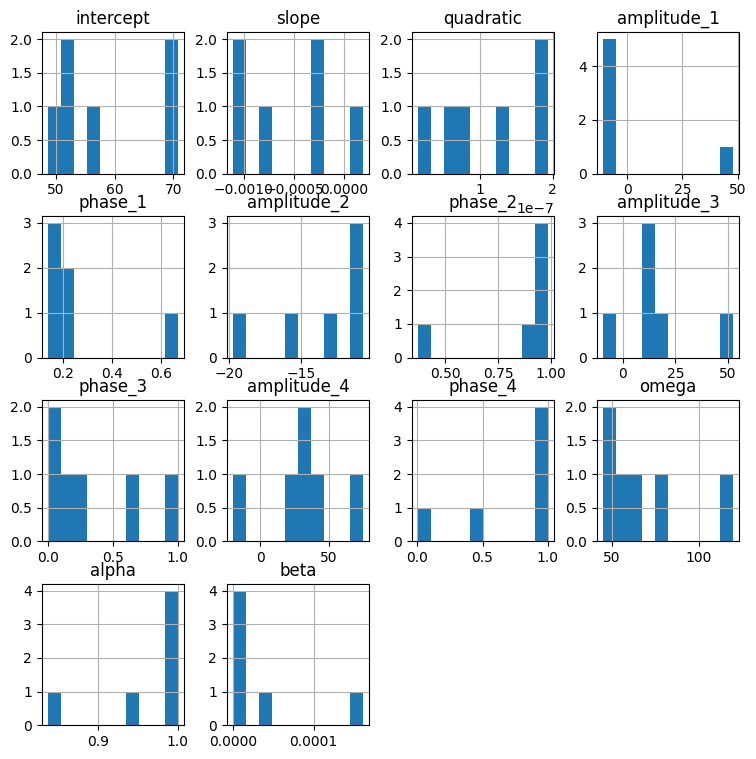

In [10]:
tmp_df = pd.DataFrame(
    {
        station: np.concat(
            [dct_fit_res[station]["fit_mean"].x, dct_fit_res[station]["fit_sgarch"].x]
        )
        for station in SET_TARGET_US_CITIES
    },
    index=[
        "intercept",
        "slope",
        "quadratic",
        "amplitude_1",
        "phase_1",
        "amplitude_2",
        "phase_2",
        "amplitude_3",
        "phase_3",
        "amplitude_4",
        "phase_4",
        "omega",
        "alpha",
        "beta",
    ],
).T
display(tmp_df.describe())
tmp_df.hist(figsize=(9, 9))

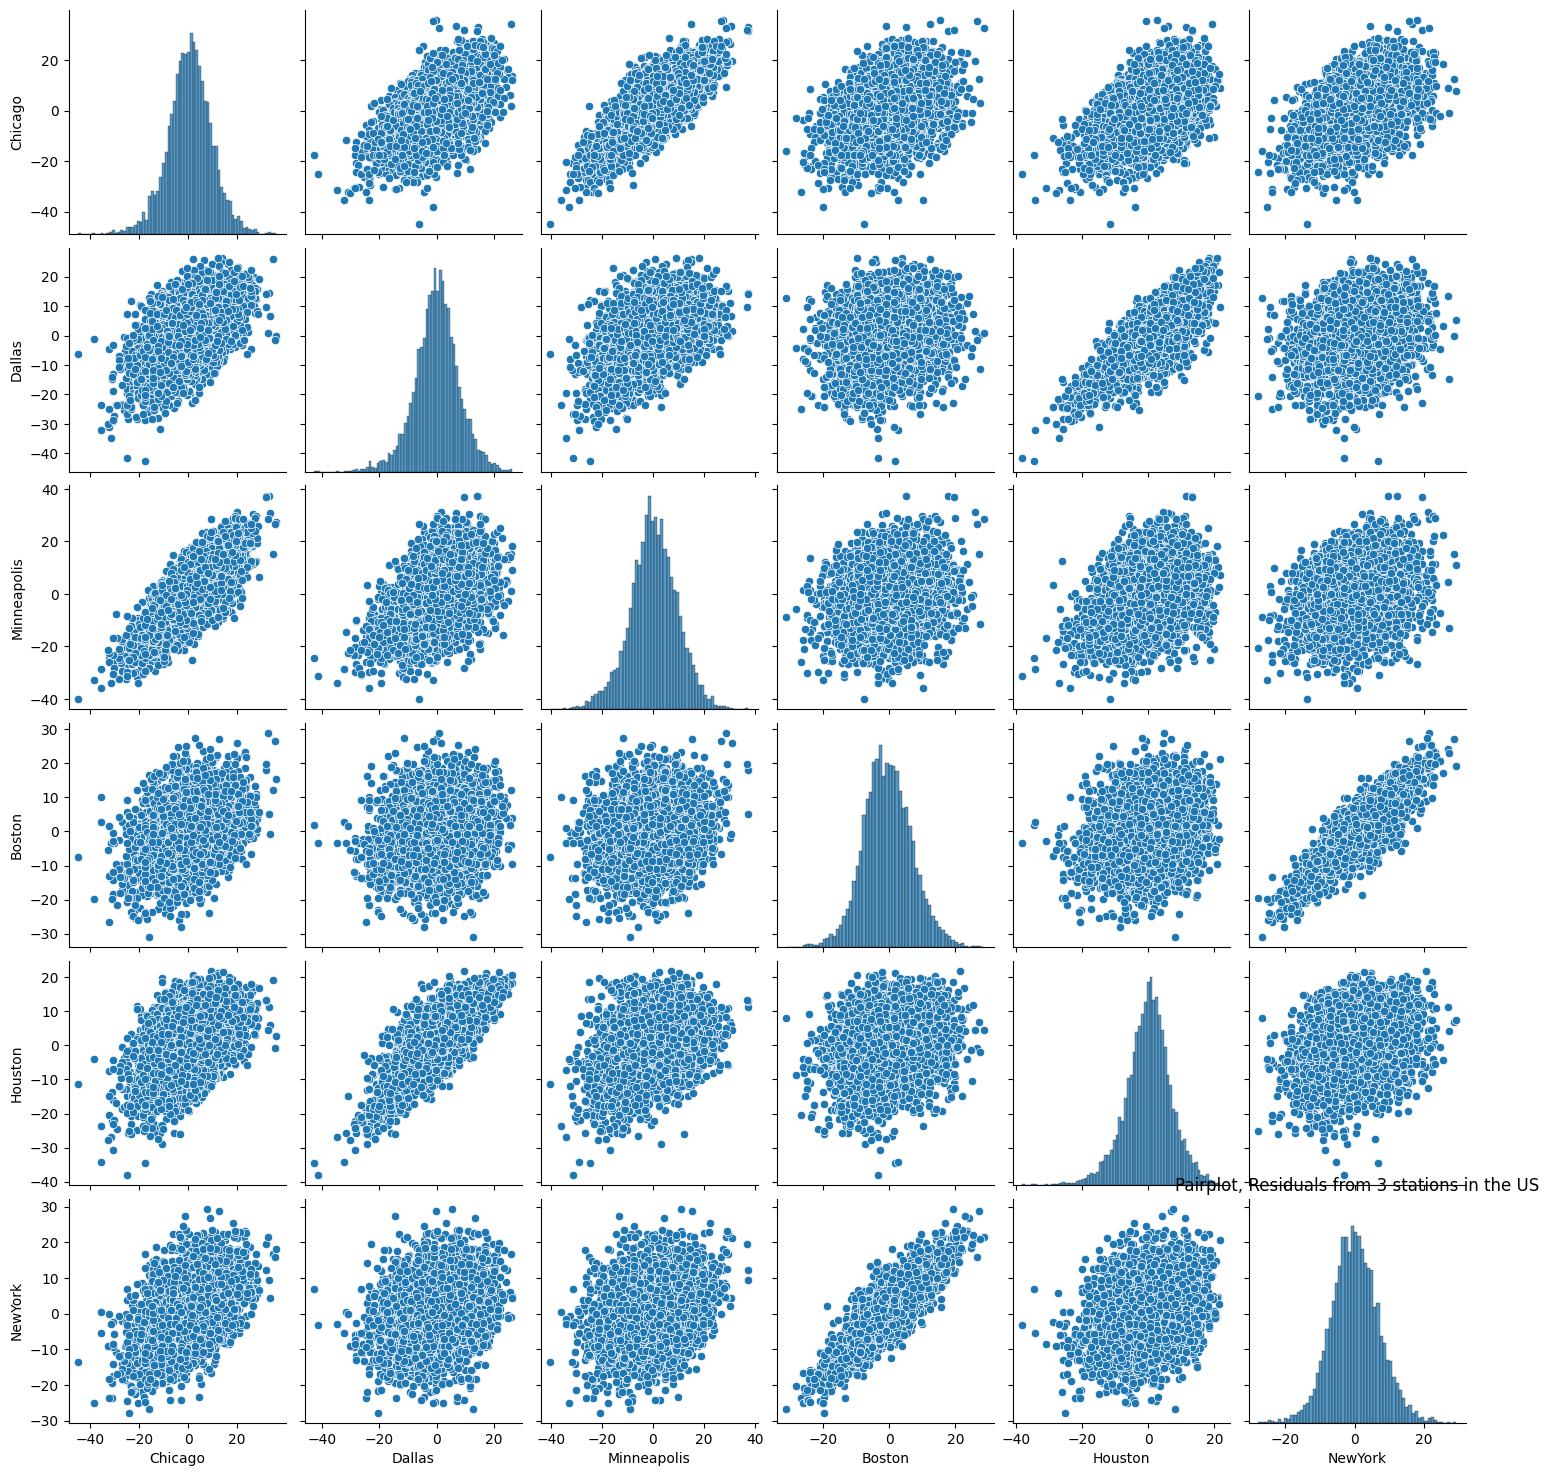

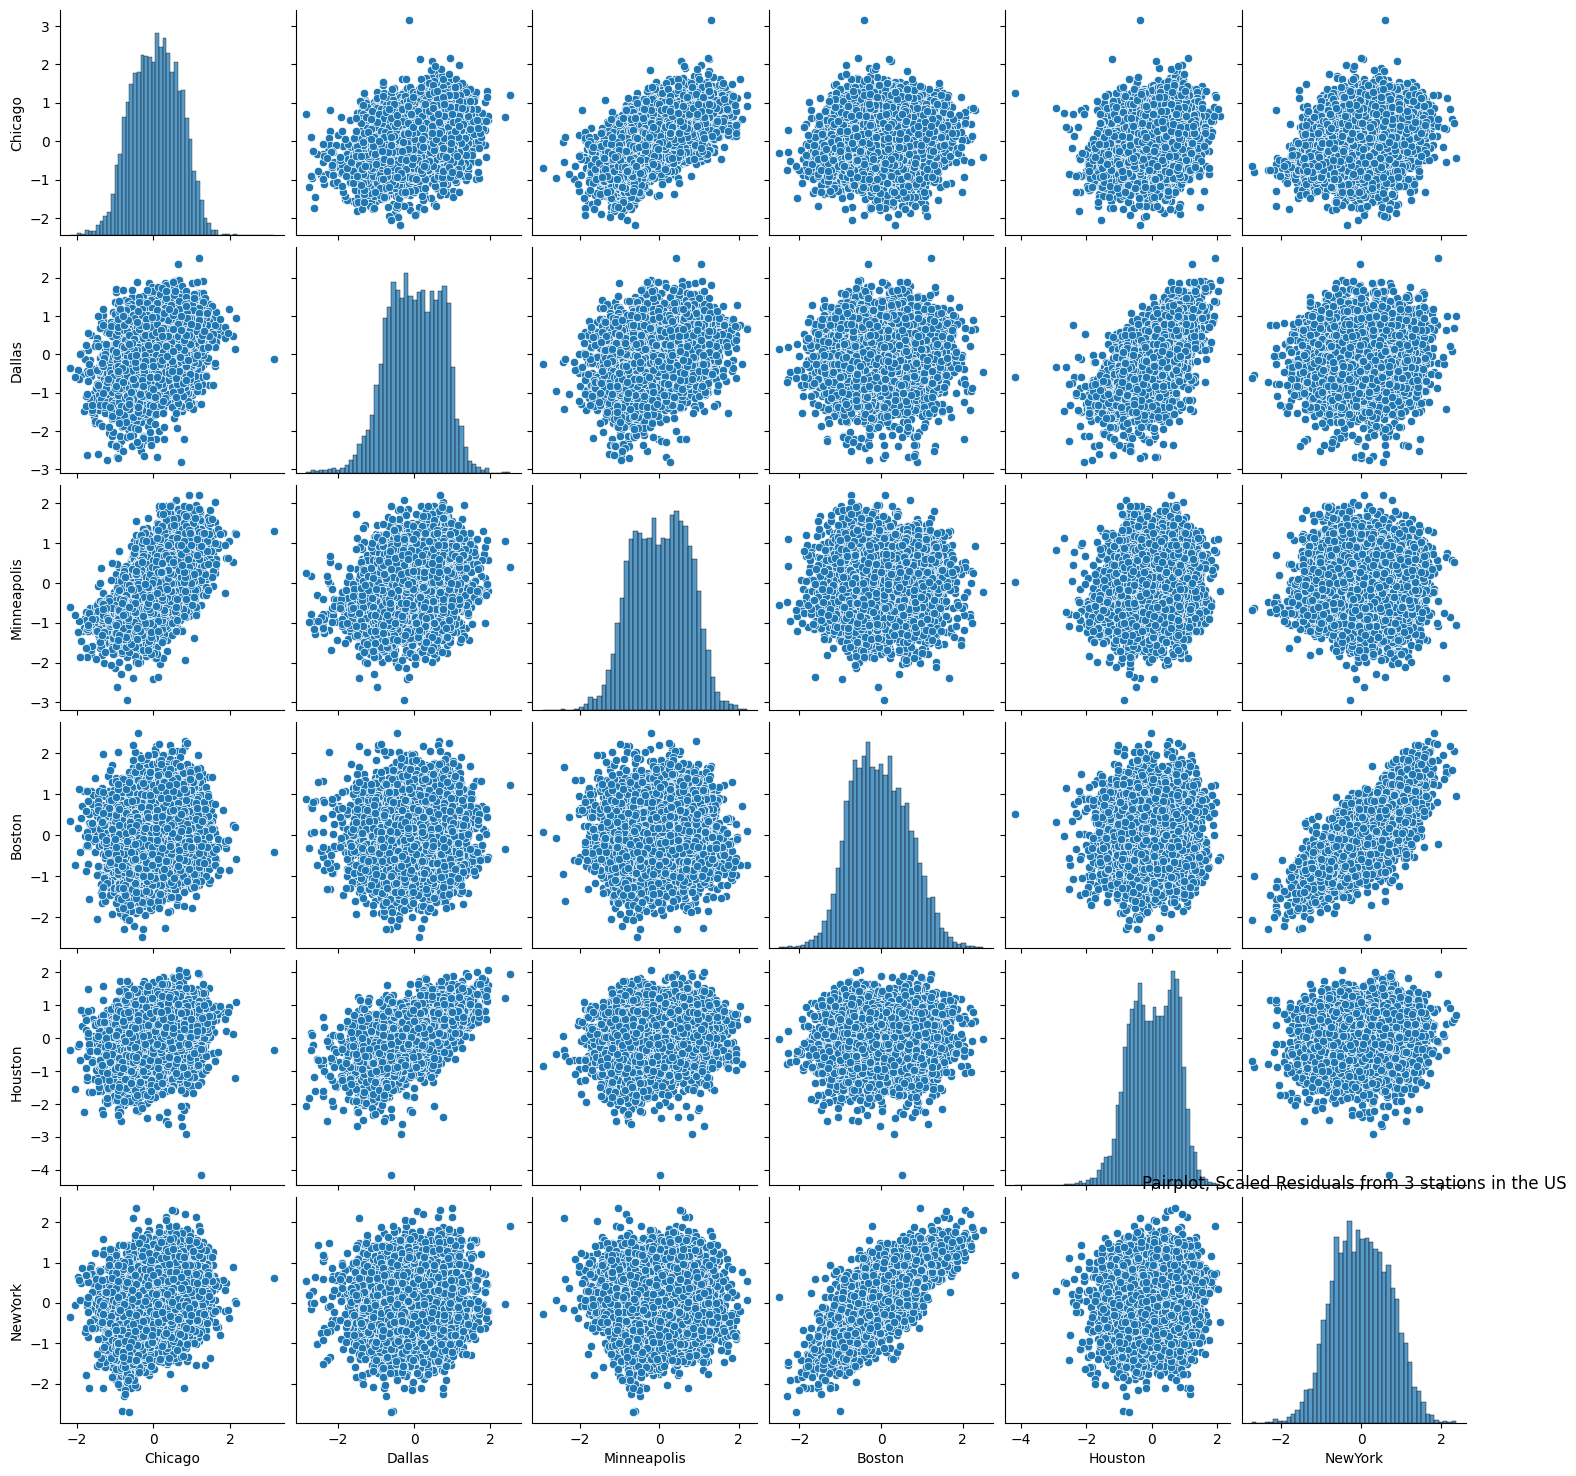

In [11]:

#
df_res = pd.DataFrame(
    {station: dct_fit_res[station]["vec_res"].values for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)
sns.pairplot(df_res)
plt.title("Pairplot, Residuals from 3 stations in the US")
#
df_res_scaled = pd.DataFrame(
    {station: dct_fit_res[station]["vec_res_scaled"].values for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)
sns.pairplot(df_res_scaled)
plt.title("Pairplot, Scaled Residuals from 3 stations in the US")
#
df_std = pd.DataFrame(
    {station: dct_fit_res[station]["vec_std"] for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)
df_y_pred = pd.DataFrame(
    {station: dct_fit_res[station]["vec_y_pred"] for station in SET_TARGET_US_CITIES},
    index=dct_fit_res[station]["vec_index"],
)

Text(0.5, 1.0, "Kendall's tau, Residuals from 3 stations in the US")

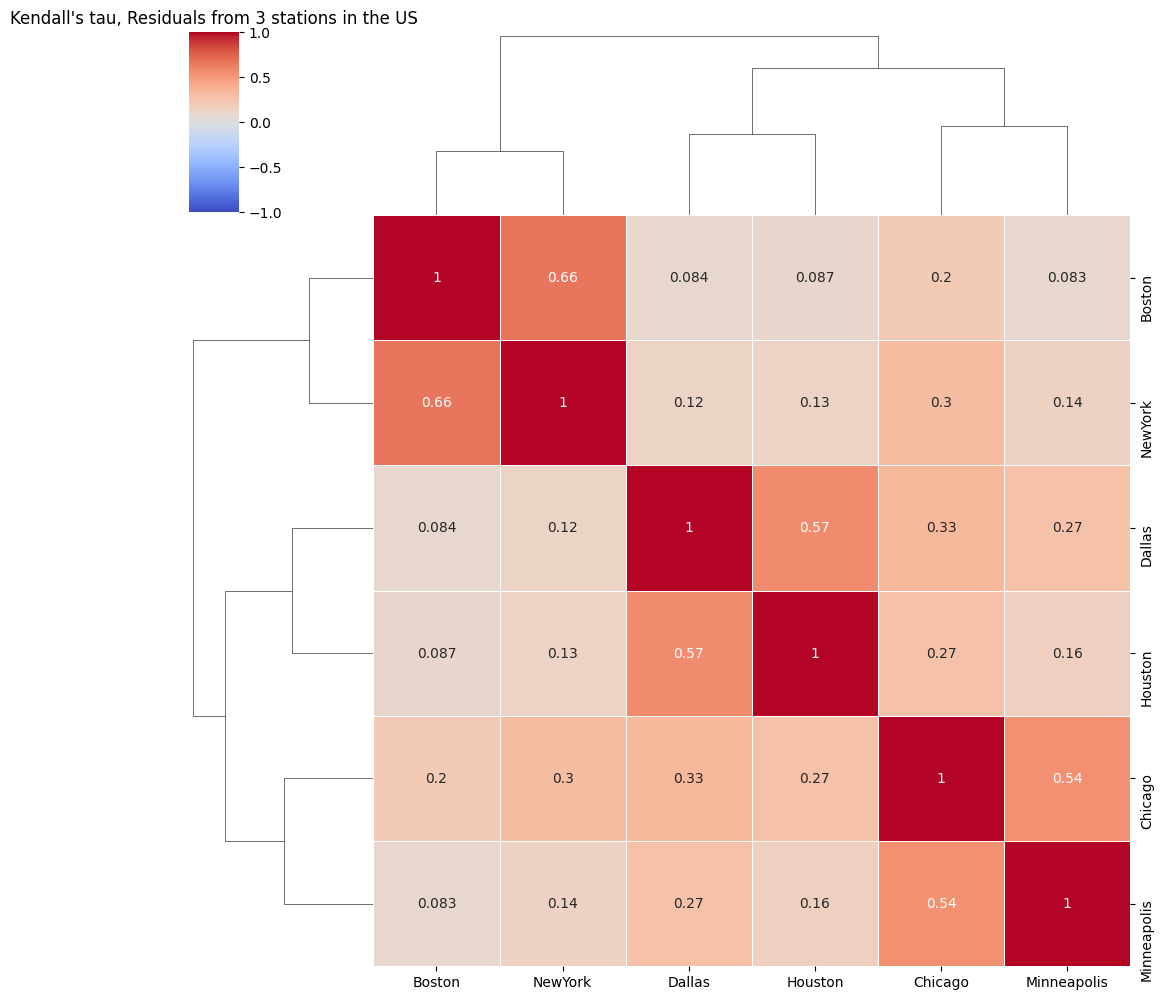

In [12]:
sns.clustermap(
    df_res.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Kendall's tau, Residuals from 3 stations in the US")

In [13]:
dct_evi_res_right = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_res[station].values
    tmp_vec = tmp_vec[tmp_vec > 0]
    dct_evi_res_right[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

In [14]:
df_evi_res_right = pd.DataFrame(dct_evi_res_right).head(7)
df_evi_res_right[df_evi_res_right < 0] = np.abs(df_evi_res_right[df_evi_res_right < 0])
df_evi_res_right[np.isinf(df_evi_res_right)] = np.nan
display(df_evi_res_right)
df_evi_res_right.median(axis=0)

,Chicago,Dallas,Minneapolis,Boston,Houston,NewYork
hill,0.018466,0.607001,1.145695,1.670908,0.556155,1.165944
schultze_steinebach,0.400492,0.340306,0.425752,0.309903,0.303189,0.305178
smith,0.197468,0.172888,0.172468,0.172466,0.152961,0.194000
meerschaert_scheffler,0.707109,0.688941,0.711803,0.688463,0.672460,0.684565
genextreme,0.109469,0.093262,0.141506,0.108778,0.108554,0.100945
genpareto,0.214661,0.229891,0.229209,0.225237,0.258044,0.211706
pareto,0.140573,0.119334,0.148287,0.088307,0.149770,0.137692


Chicago        0.197468
Dallas         0.229891
Minneapolis    0.229209
Boston         0.225237
Houston        0.258044
NewYork        0.211706
dtype: float64

In [15]:
dct_evi_res_left = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_res[station].values
    tmp_vec = -tmp_vec[tmp_vec < 0]
    dct_evi_res_left[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

In [16]:
df_evi_res_left = pd.DataFrame(dct_evi_res_left).head(7)
df_evi_res_left[df_evi_res_left < 0] = np.abs(df_evi_res_left[df_evi_res_left < 0])
df_evi_res_left[np.isinf(df_evi_res_left)] = np.nan
display(df_evi_res_left)
df_evi_res_left.median(axis=0)

,Chicago,Dallas,Minneapolis,Boston,Houston,NewYork
hill,1.210509,3.269672,1.052017,0.459434,0.376967,1.445448
schultze_steinebach,0.344344,0.257697,0.310519,0.299572,0.267948,0.277413
smith,0.230931,0.231517,0.173529,0.207199,0.233914,0.208551
meerschaert_scheffler,0.714786,0.703343,0.720634,0.679608,0.693545,0.675400
genextreme,0.040978,0.001580,0.042412,0.126015,0.006547,0.098926
genpareto,0.148393,0.114874,0.176345,0.216097,0.121871,0.205051
pareto,0.102032,0.145724,0.108433,0.121494,0.114316,0.154010


Chicago        0.230931
Dallas         0.231517
Minneapolis    0.176345
Boston         0.216097
Houston        0.233914
NewYork        0.208551
dtype: float64

In [17]:
df_avg_all_target = df_avg_all[list(SET_TARGET_US_CITIES)]

df_cdd = (df_avg_all_target[df_avg_all_target.index.month.isin(MONTH_CDD)] - 65).clip(lower=0)
df_cdd.describe()

,Chicago,Dallas,Minneapolis,Boston,Houston,NewYork
count,3060.000000,3060.000000,3060.000000,3060.000000,3060.000000,3060.000000
mean,6.552288,17.724837,6.031536,5.753758,17.745098,9.171078
std,5.902378,6.669455,5.723174,5.820619,4.947656,6.692291
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13.500000,0.000000,0.000000,15.000000,3.000000
50%,6.000000,19.000000,5.000000,4.500000,18.500000,9.500000
75%,11.500000,22.500000,10.000000,10.000000,21.000000,14.000000
max,27.500000,32.500000,26.000000,27.000000,30.000000,29.500000


Text(0.5, 1.0, 'Pairplot, CDD from 3 stations in the US')

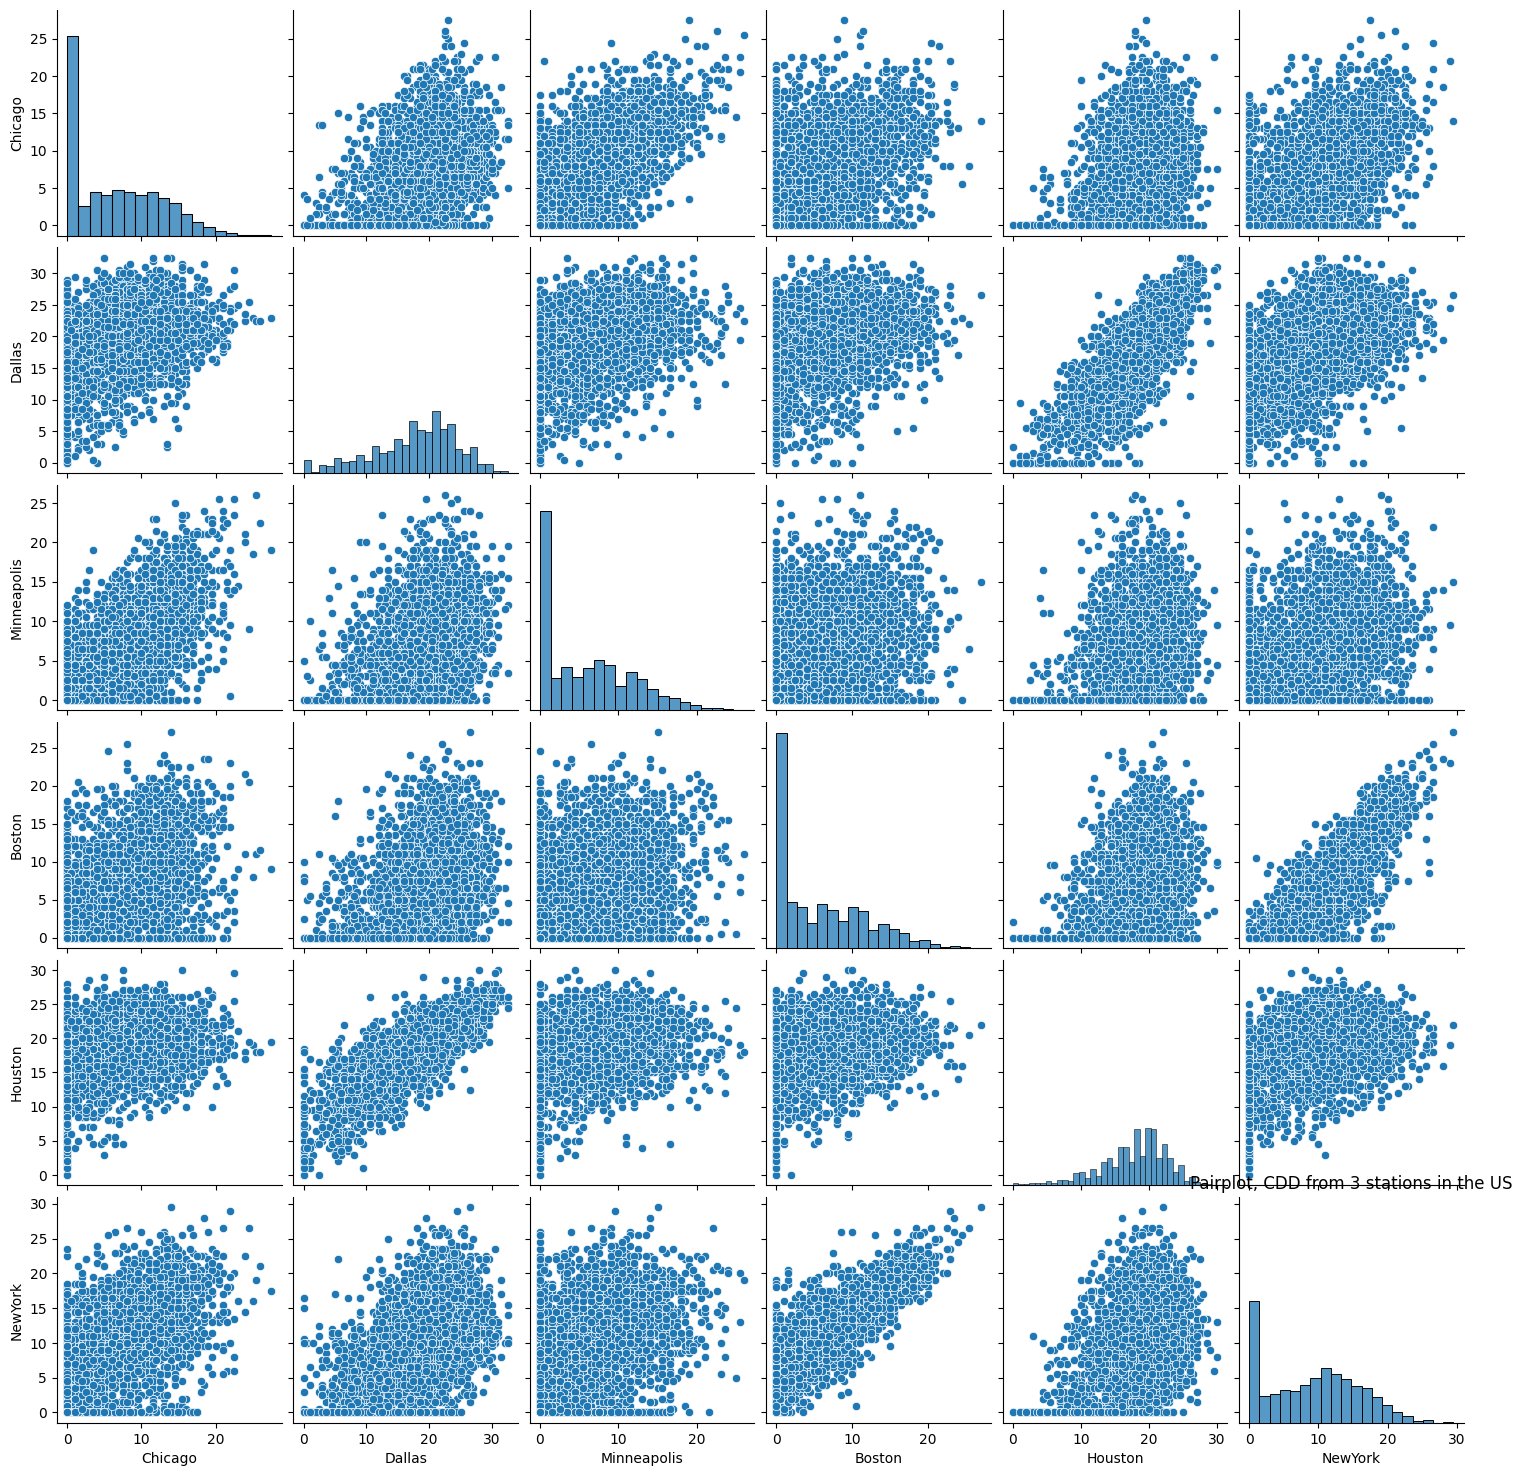

In [18]:
sns.pairplot(df_cdd)
plt.title("Pairplot, CDD from 3 stations in the US")

Text(0.5, 1.0, "Kendall's tau, CDD from 3 stations in the US")

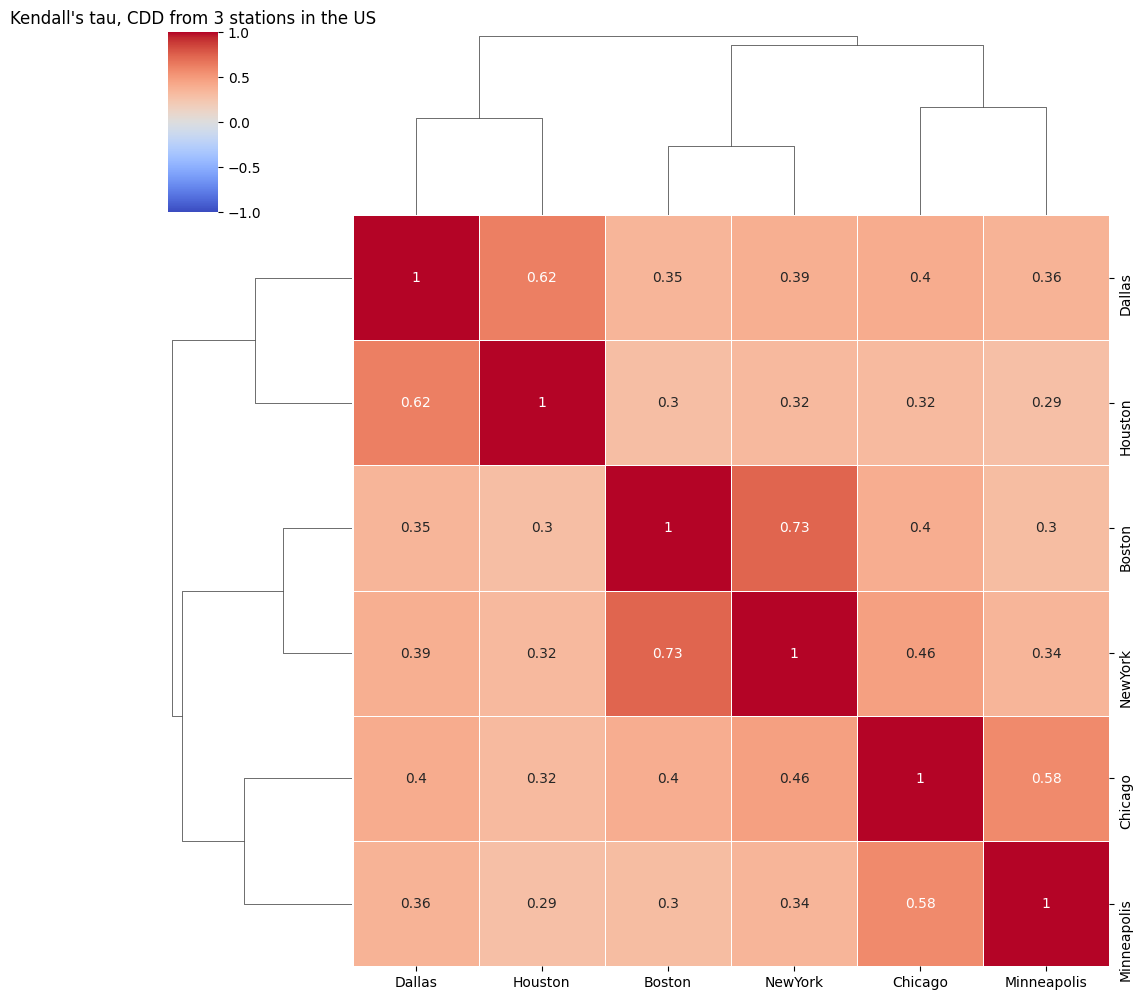

In [19]:
sns.clustermap(
    df_cdd.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Kendall's tau, CDD from 3 stations in the US")

In [20]:
dct_evi_cdd = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_cdd[station].values
    dct_evi_cdd[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

/home/codespace/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:8244: RuntimeWarning: divide by zero encountered in divide
  return ndata / np.sum(np.log((data - location) / scale))
/home/codespace/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:8244: RuntimeWarning: invalid value encountered in divide
  return ndata / np.sum(np.log((data - location) / scale))


In [21]:
df_evi_cdd = pd.DataFrame(dct_evi_cdd).head(7)
df_evi_cdd[df_evi_cdd < 0] = np.abs(df_evi_cdd[df_evi_cdd < 0])
df_evi_cdd[np.isinf(df_evi_cdd)] = np.nan
display(df_evi_cdd)
df_evi_cdd.median(axis=0)

,Chicago,Dallas,Minneapolis,Boston,Houston,NewYork
hill,NaN,0.092878,NaN,NaN,0.049777,NaN
schultze_steinebach,NaN,0.673950,NaN,NaN,0.691739,NaN
smith,0.136486,0.064317,0.155848,0.125682,0.059270,0.112467
meerschaert_scheffler,0.721175,0.736399,0.717334,0.719438,0.699192,0.736824
genextreme,0.139809,0.696606,2.446117,3.035287,0.744789,0.351044
genpareto,0.292913,0.909735,3.079065,3.079236,0.986001,0.436815
pareto,NaN,NaN,NaN,NaN,NaN,NaN


Chicago        0.216361
Dallas         0.685278
Minneapolis    1.581726
Boston         1.877362
Houston        0.695466
NewYork        0.393929
dtype: float64

Text(0.5, 1.0, 'Pairplot, CDD residuals from 13 stations in the US')

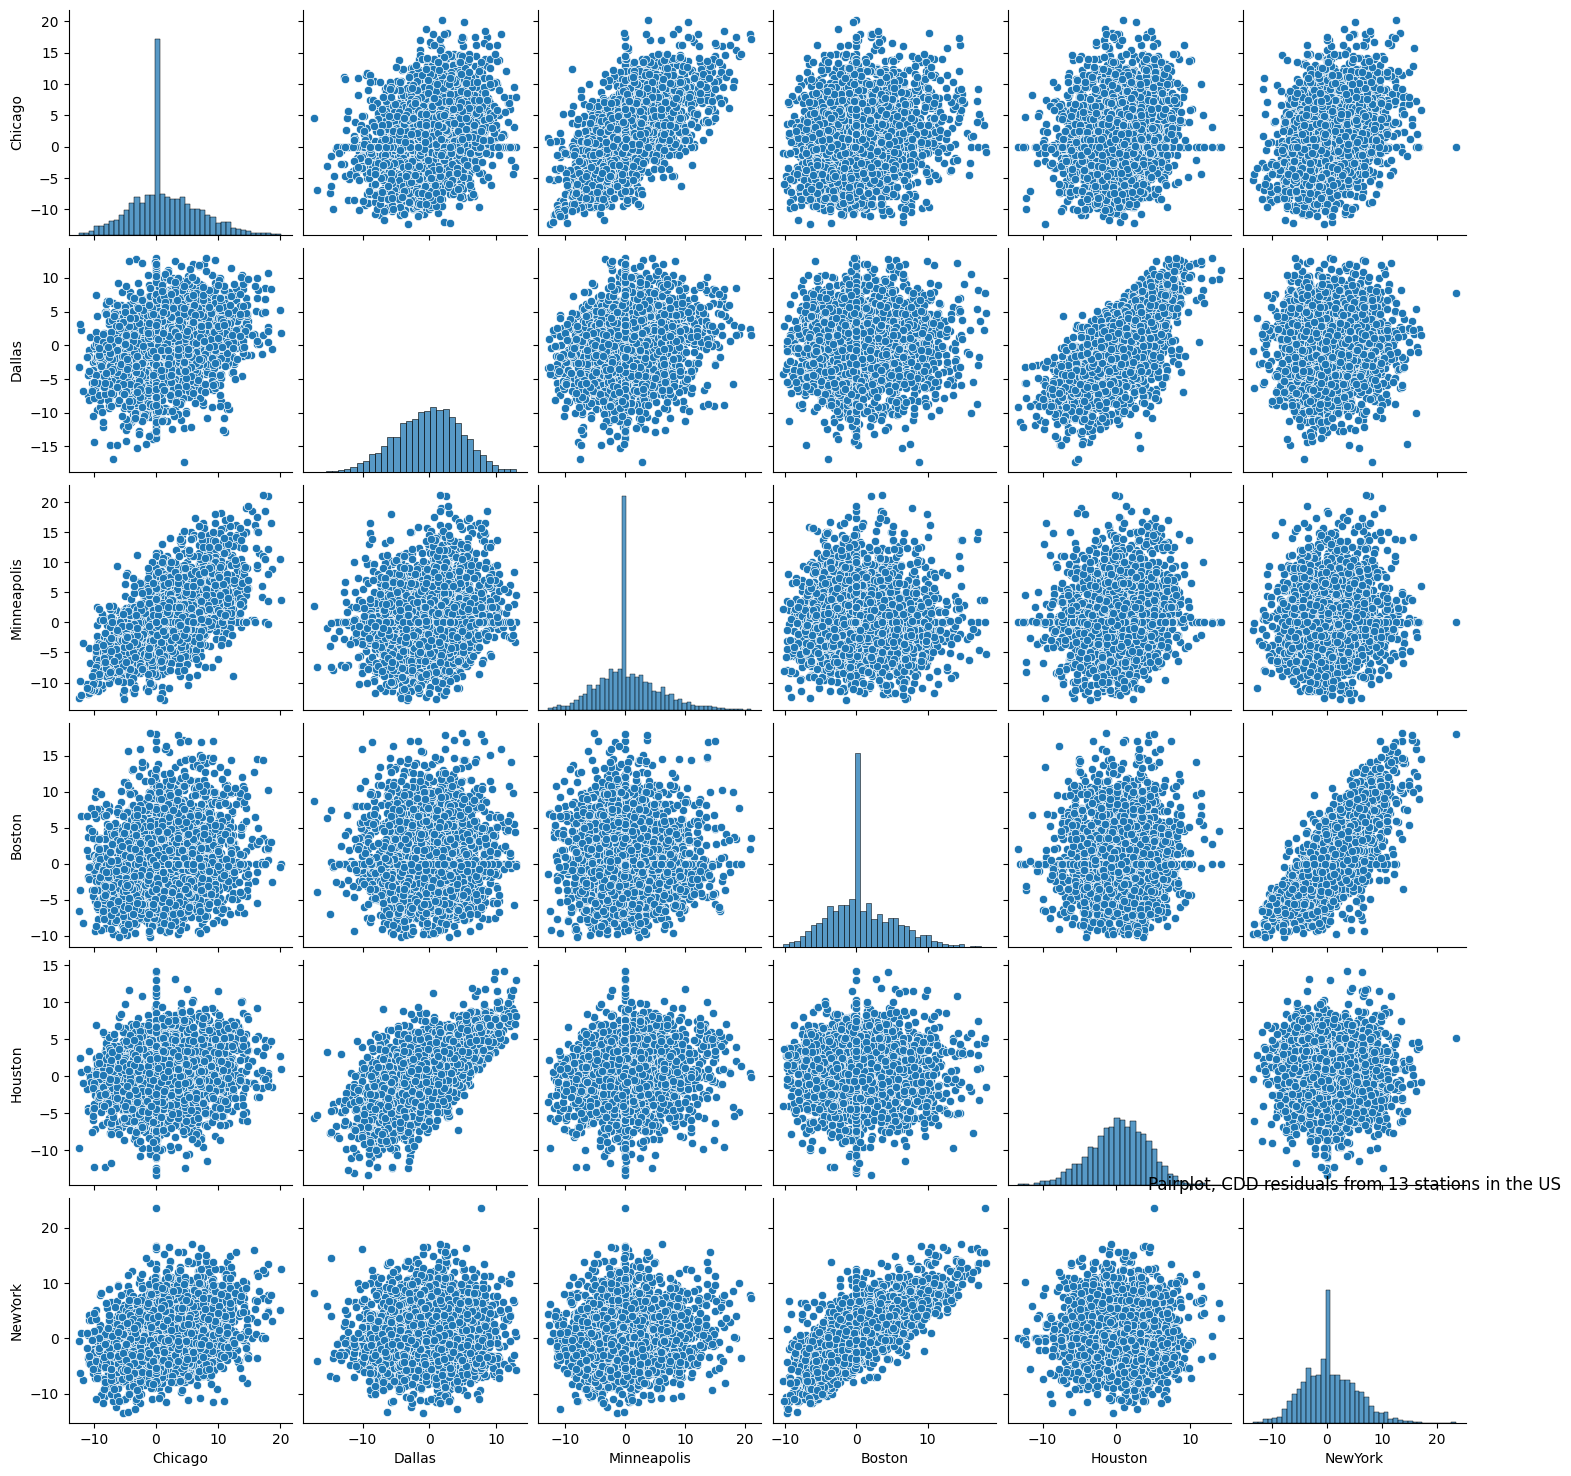

In [22]:
df_cdd_pred = (
    pd.DataFrame(
        {station: dct_fit_res[station]["vec_y_pred"].values for station in SET_TARGET_US_CITIES},
        index=dct_fit_res[station]["vec_index"],
    )
    - 65
).clip(lower=0)
df_cdd_pred = df_cdd_pred[df_cdd_pred.index.month.isin(MONTH_CDD)]
df_cdd_res = df_cdd - df_cdd_pred
sns.pairplot(df_cdd_res)
plt.title("Pairplot, CDD residuals from 13 stations in the US")

Text(0.5, 1.0, "Kendall's tau, CDD residuals from 13 stations in the US")

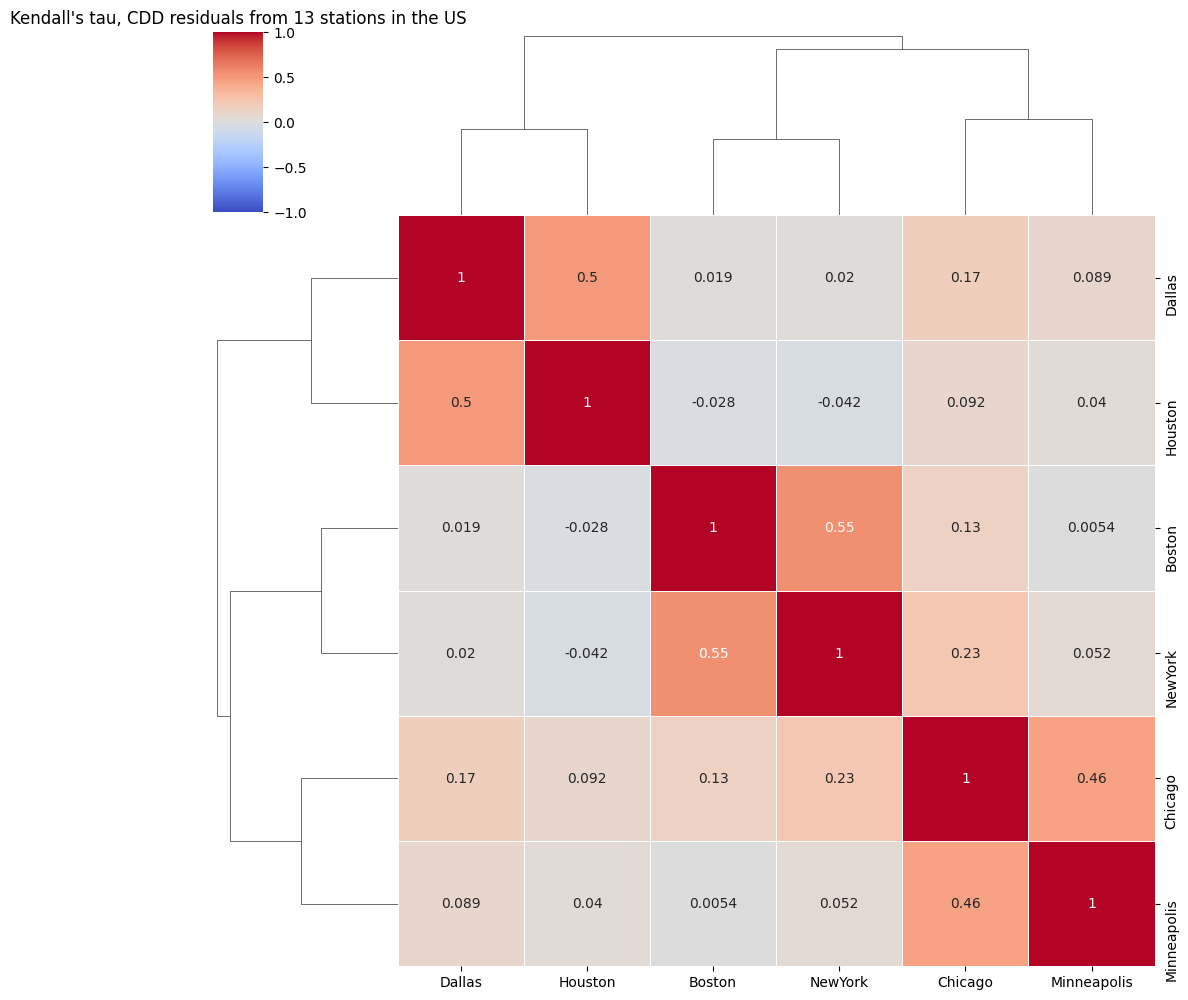

In [23]:
g = sns.clustermap(
    df_cdd_res.corr(method="kendall"),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.title("Kendall's tau, CDD residuals from 13 stations in the US")

In [24]:
dct_evi_cdd_res_right = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_cdd_res[station].values
    # ! right tail
    tmp_vec = tmp_vec[tmp_vec > 0]
    dct_evi_cdd_res_right[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

In [25]:
df_evi_cdd_res_right = pd.DataFrame(dct_evi_cdd_res_right).head(7)
df_evi_cdd_res_right[df_evi_cdd_res_right < 0] = np.abs(
    df_evi_cdd_res_right[df_evi_cdd_res_right < 0]
)
df_evi_cdd_res_right[np.isinf(df_evi_cdd_res_right)] = np.nan
display(df_evi_cdd_res_right)
df_evi_cdd_res_right.median(axis=0)

,Chicago,Dallas,Minneapolis,Boston,Houston,NewYork
hill,0.139787,0.453942,1.590814,0.998896,0.640983,0.378792
schultze_steinebach,0.308946,0.249812,0.321362,0.250270,0.217668,0.220291
smith,0.151673,0.148448,0.166546,0.192797,0.174259,0.175908
meerschaert_scheffler,0.688492,0.634362,0.692627,0.677915,0.611883,0.666814
genextreme,0.213481,0.222855,0.117054,0.187433,0.176997,0.149199
genpareto,0.338747,0.361352,0.255702,0.317914,0.263584,0.219172
pareto,0.193934,0.125320,0.158190,0.089483,0.160127,0.164472


Chicago        0.213481
Dallas         0.249812
Minneapolis    0.255702
Boston         0.250270
Houston        0.217668
NewYork        0.219172
dtype: float64

In [26]:
dct_evi_cdd_res_left = {}
for station in SET_TARGET_US_CITIES:
    tmp_vec = df_cdd_res[station].values
    # ! left tail
    tmp_vec = -tmp_vec[tmp_vec < 0]
    dct_evi_cdd_res_left[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        # ! is_frechet=False
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)[
            "slope_emr"
        ],
    }

In [27]:
df_evi_cdd_res_left = pd.DataFrame(dct_evi_cdd_res_left).head(7)
df_evi_cdd_res_left[df_evi_cdd_res_left < 0] = np.abs(
    df_evi_cdd_res_left[df_evi_cdd_res_left < 0]
)
df_evi_cdd_res_left[np.isinf(df_evi_cdd_res_left)] = np.nan
display(df_evi_cdd_res_left)
df_evi_cdd_res_left.median(axis=0)

,Chicago,Dallas,Minneapolis,Boston,Houston,NewYork
hill,1.300821,0.758499,0.569301,0.665708,2.986537,1.820985
schultze_steinebach,0.282604,0.218767,0.266258,0.165050,0.171292,0.218325
smith,0.092110,0.151132,0.151410,0.128345,0.174431,0.184707
meerschaert_scheffler,0.644352,0.653962,0.644581,0.619999,0.629270,0.629946
genextreme,0.259379,0.181979,0.226223,0.317406,0.126531,0.221222
genpareto,0.408652,0.288972,0.379539,0.473150,0.264147,0.334925
pareto,0.160620,0.153778,0.115542,0.130021,0.172639,0.198317


Chicago        0.282604
Dallas         0.218767
Minneapolis    0.266258
Boston         0.317406
Houston        0.174431
NewYork        0.221222
dtype: float64

In [28]:
with open('../data/processed/all_analysis_data.pkl', 'wb') as f:
    pickle.dump({
        'df_boston': df_boston,
        'df_ny': df_ny,
        'df_houston': df_houston,
        'df_chicago': df_chicago,
        'df_dallas': df_dallas,
        'df_minneapolis': df_minneapolis,
        'df_res': df_res,
        'df_cdd_load_res': df_cdd_load_res,
        'df_hdd_load_res': df_hdd_load_res,
        'df_result': df_result,
        'region_fits': region_fits,
        'all_regions_comparison': all_regions_comparison,
        'df_tdc_load_cdd_res': df_tdc_load_cdd_res,
        'df_tdc_load_hdd_res': df_tdc_load_hdd_res,
        'dct_evi_load_res_right': dct_evi_load_res_right,
        'dct_evi_load_res_left': dct_evi_load_res_left,
        'df_evi_res_right': df_evi_res_right,
        'df_evi_res_left': df_evi_res_left,
    }, f)

print("✓ All data saved to '../data/processed/all_analysis_data.pkl'")


NameError: name 'df_boston' is not defined